# Cluster Summary — Papers

Cluster-level summaries and figures for the papers topic model.

This notebook computes citation/year-normalized metrics per topic and exports:
- `assets/reports/cluster_summary.tsv`

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

ASSETS = os.path.join('..', 'assets')
MODELS = os.path.join(ASSETS, 'topic_models')
REPORTS = os.path.join(ASSETS, 'reports')
os.makedirs(REPORTS, exist_ok=True)

In [2]:
# Load papers dataset
papers = pd.read_csv(os.path.join(ASSETS, 'synbio_openalex.txt'), sep='\t')

# Load topic assignments and topic names
doc_topics = pd.read_csv(os.path.join(MODELS, 'papers_doc_topics.txt'), sep='\t')
topic_names = pd.read_csv(os.path.join(MODELS, 'papers_topic_names.txt'), sep='\t')

# Merge topics into papers
papers = papers.merge(doc_topics, on='id', how='left')
papers = papers.merge(topic_names[['topic', 'global_name']], on='topic', how='left')

# Basic cleaning
papers['cited_by_count'] = pd.to_numeric(papers['cited_by_count'], errors='coerce').fillna(0).astype(int)
papers['publication_year'] = pd.to_numeric(papers['publication_year'], errors='coerce')

print(f"Papers: {len(papers):,}")
print(f"Topics: {papers['topic'].nunique()} (incl. outlier -1)")
papers.head(3)

Papers: 19,017
Topics: 226 (incl. outlier -1)


,id,doi,title,publication_year,language,type,source_id,source_name,authors,institutions,countries,cited_by_count,abstract,concepts,referenced_works,topic,global_name
0,https://openalex.org/W1984248485,https://doi.org/10.1126/science.1190719,Creation of a Bacterial Cell Controlled by a C...,2010,en,article,https://openalex.org/S3880285,Science,Daniel G. Gibson; John I. Glass; Carole Lartig...,J. Craig Venter Institute,USA,2622,"We report the design, synthesis, and assembly ...",Mycoplasma mycoides; Genome; Biology; Gene; Ge...,0.0,-1,NaN
1,https://openalex.org/W219375404,https://doi.org/10.5860/choice.51-5390,"Speculative everything: design, fiction, and s...",2014,en,article,https://openalex.org/S2764375719,Choice Reviews Online,NaN,NaN,NaN,1983,Today designers often focus on making technolo...,History; Aesthetics; Literature; Art,0.0,199,Future Societal Implications of Synthetic Biology
2,https://openalex.org/W2304674135,https://doi.org/10.1126/science.aad6253,Design and synthesis of a minimal bacterial ge...,2016,en,article,https://openalex.org/S3880285,Science,Clyde A. Hutchison; Ray-Yuan Chuang; Vladimir ...,J. Craig Venter Institute; National Institute ...,USA,1506,We used whole-genome design and complete chemi...,Genome; Gene; Biology; Genetics; Mycoplasma my...,0.0,-1,NaN


## Yearly-normalized citations

Three normalization approaches applied per publication year:
- **Z-norm**: z-score of raw citations within each year
- **Log**: z-score of log(1 + citations) within each year
- **Rank**: percentile rank of citations within each year (0-1)

In [3]:
# Log transform (applied before z-scoring)
papers['log_citations'] = np.log1p(papers['cited_by_count'])

# Z-norm: z-score of raw citations per year
papers['TC_znorm'] = papers.groupby('publication_year')['cited_by_count'].transform(
    lambda x: zscore(x, ddof=1) if len(x) > 1 else 0.0
)

# Log z-norm: z-score of log(1+citations) per year
papers['TC_log'] = papers.groupby('publication_year')['log_citations'].transform(
    lambda x: zscore(x, ddof=1) if len(x) > 1 else 0.0
)

# Rank: percentile rank per year (0 = least cited, 1 = most cited)
papers['TC_rank'] = papers.groupby('publication_year')['cited_by_count'].transform(
    lambda x: x.rank(pct=True)
)

papers[['id', 'publication_year', 'cited_by_count', 'TC_znorm', 'TC_log', 'TC_rank']].describe().round(3)

,publication_year,cited_by_count,TC_znorm,TC_log,TC_rank
count,19017.000,19017.000,19017.000,19017.000,19017.000
mean,2017.665,24.038,-0.000,0.000,0.501
std,5.635,66.334,0.999,0.999,0.284
min,2004.000,0.000,-0.670,-1.643,0.076
25%,2014.000,0.000,-0.452,-0.819,0.257
50%,2019.000,6.000,-0.294,0.047,0.498
75%,2023.000,24.000,0.062,0.771,0.747
max,2025.000,2622.000,20.989,3.888,1.000


## Cluster-level summary

Average citations and normalized metrics per topic, plus recency measures:
- **avg_year**: plain average publication year
- **price_index**: fraction of papers from the last 5 years
- **avg_year_rank**: average percentile-rank of publication year across the full corpus

In [4]:
# Exclude outlier topic -1
papers_valid = papers[papers['topic'] >= 0].copy()

# Price Index: % of papers from the last 5 years
max_year = int(papers_valid['publication_year'].max())
papers_valid['is_recent'] = (papers_valid['publication_year'] >= max_year - 4).astype(int)

# Year-rank recency
papers_valid['year_rank'] = papers_valid['publication_year'].rank(pct=True)

cluster_summary = papers_valid.groupby('topic').agg(
    n_papers=('id', 'size'),
    avg_citations=('cited_by_count', 'mean'),
    avg_TC_znorm=('TC_znorm', 'mean'),
    avg_TC_log=('TC_log', 'mean'),
    avg_TC_rank=('TC_rank', 'mean'),
    avg_year=('publication_year', 'mean'),
    price_index=('is_recent', 'mean'),
    avg_year_rank=('year_rank', 'mean'),
).reset_index()

cluster_summary = cluster_summary.merge(
    topic_names[['topic', 'global_name']], on='topic', how='left'
)

cluster_summary_out = os.path.join(REPORTS, 'cluster_summary_papers.tsv')
cluster_summary.to_csv(cluster_summary_out, sep='\t', index=False)

print(f"Clusters: {len(cluster_summary)}")
print(f"Price Index window: {max_year-4}-{max_year}")
print(f"Saved: {cluster_summary_out}")
cluster_summary.sort_values('avg_TC_log', ascending=False).head(10)

Clusters: 225
Price Index window: 2021-2025
Saved: ../assets/reports/cluster_summary_papers.tsv


,topic,n_papers,avg_citations,avg_TC_znorm,avg_TC_log,avg_TC_rank,avg_year,price_index,avg_year_rank,global_name
198,198,23,29.695652,0.794294,0.937331,0.746514,2021.782609,0.652174,0.720183,Synthetic Biology and Phase Separation
200,200,22,53.681818,0.658160,0.812813,0.717326,2019.090909,0.500000,0.578407,Nitrogen Fixation Engineering
19,19,109,33.844037,0.870885,0.770253,0.704610,2022.596330,0.825688,0.774409,Biomolecular Condensates and Coacervates
148,148,31,41.838710,0.891109,0.680068,0.668307,2018.645161,0.387097,0.534364,Enzyme Scaffolding and Biocatalysis
72,72,56,29.285714,0.265694,0.632737,0.688478,2019.517857,0.535714,0.591775,Cyanobacterial Synthetic Biology
107,107,41,51.414634,0.344131,0.617844,0.671775,2018.292683,0.317073,0.505793,Protein Interaction Modules
114,114,39,33.256410,0.576549,0.605076,0.669443,2022.538462,0.743590,0.764375,AI for Biological Parts Design
162,162,27,55.111111,0.452270,0.604332,0.671366,2017.407407,0.259259,0.449966,Synthetic Promoter Design
150,150,30,44.233333,0.443762,0.547790,0.669799,2020.200000,0.500000,0.617696,Yarrowia lipolytica Engineering
85,85,50,31.900000,0.315273,0.533093,0.647628,2019.200000,0.460000,0.575745,RNA Nanostructures and Devices


### Impact vs Recency scatterplot
Each dot is a topic. X = average publication year, Y = average log-normalized citations, size proportional to number of papers.

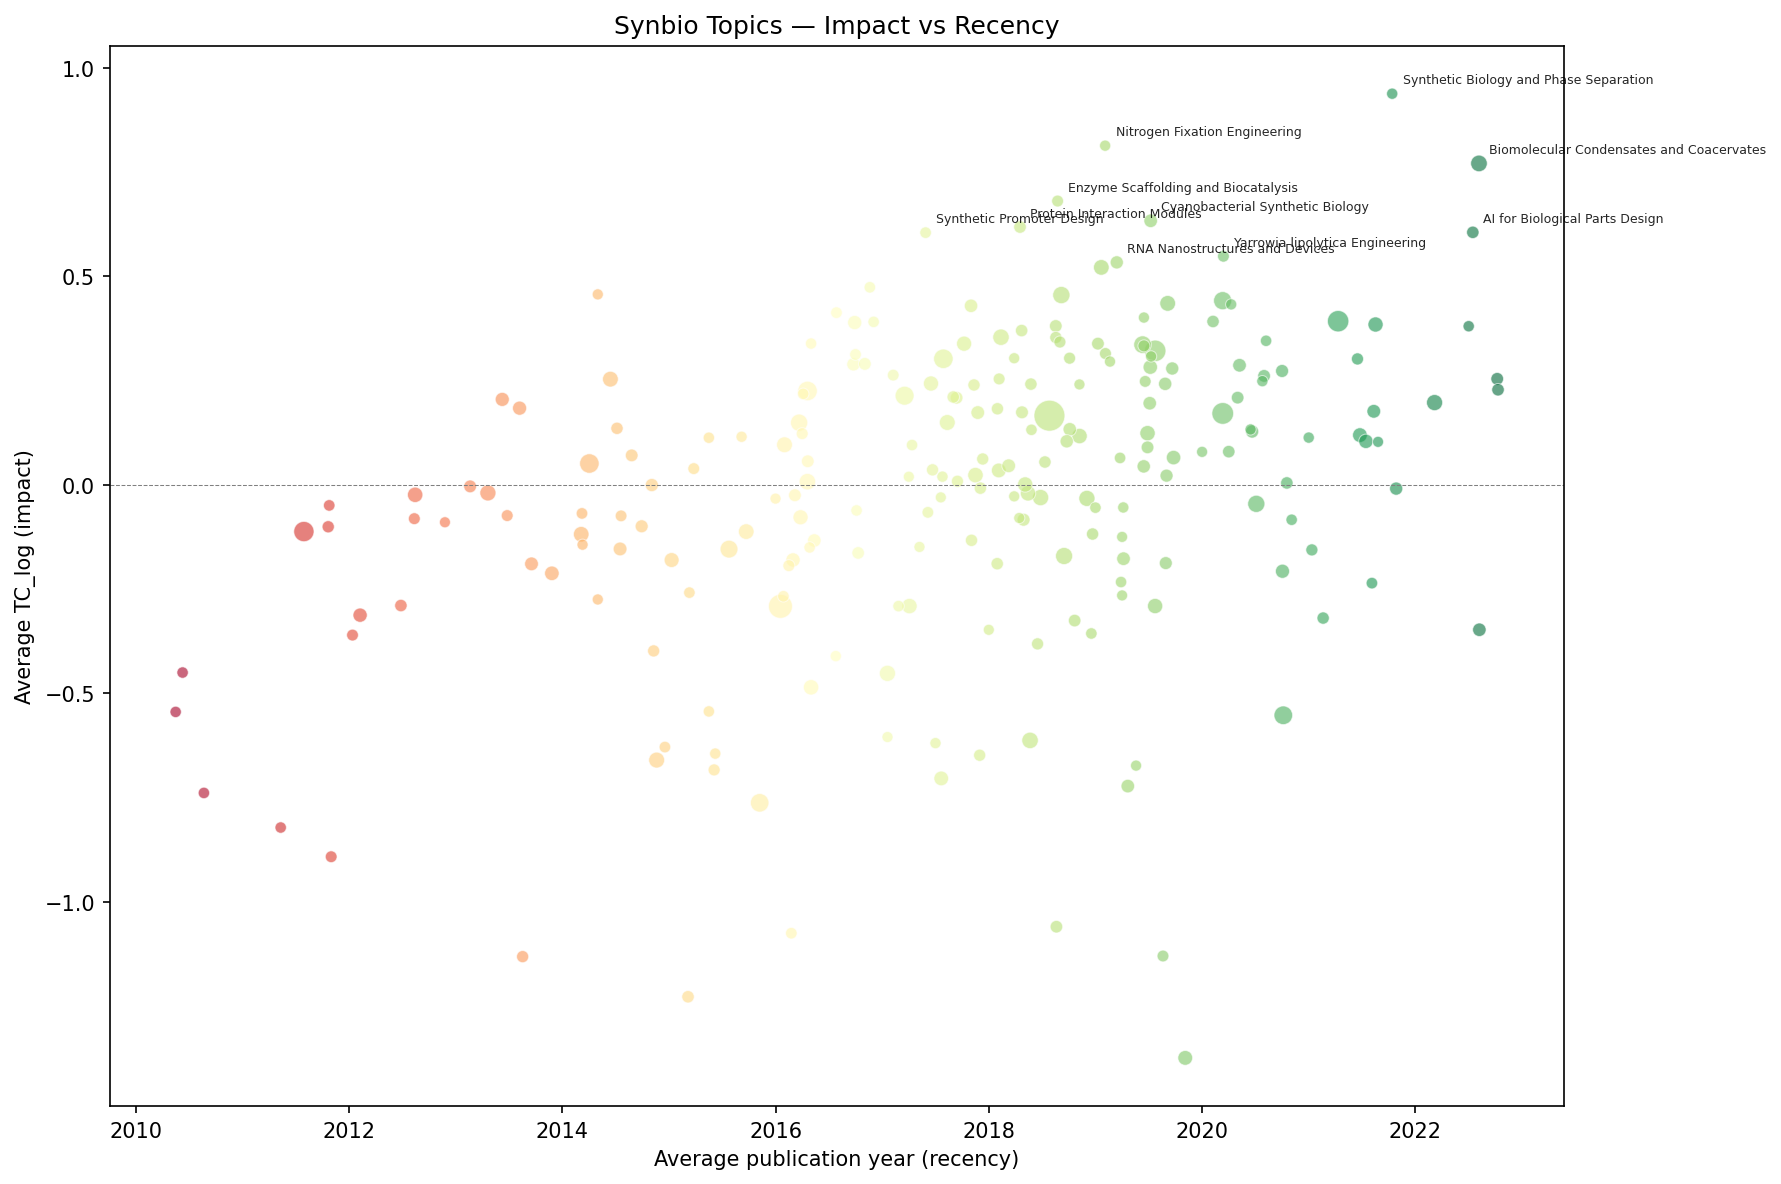

In [5]:
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

sizes = 20 + 200 * (cluster_summary['n_papers'] / cluster_summary['n_papers'].max())

ax.scatter(
    cluster_summary['avg_year'],
    cluster_summary['avg_TC_log'],
    s=sizes,
    alpha=0.6,
    edgecolors='white',
    linewidth=0.5,
    c=cluster_summary['avg_year'],
    cmap='RdYlGn',
)

top_n = 10
for idx in cluster_summary.nlargest(top_n, 'avg_TC_log').index:
    row = cluster_summary.loc[idx]
    ax.annotate(
        row['global_name'],
        (row['avg_year'], row['avg_TC_log']),
        fontsize=6, alpha=0.85,
        textcoords='offset points', xytext=(5, 5),
    )

ax.set_xlabel('Average publication year (recency)')
ax.set_ylabel('Average TC_log (impact)')
ax.set_title('Synbio Topics — Impact vs Recency')
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()

Saved → ../assets/reports/impact_vs_price_index.png


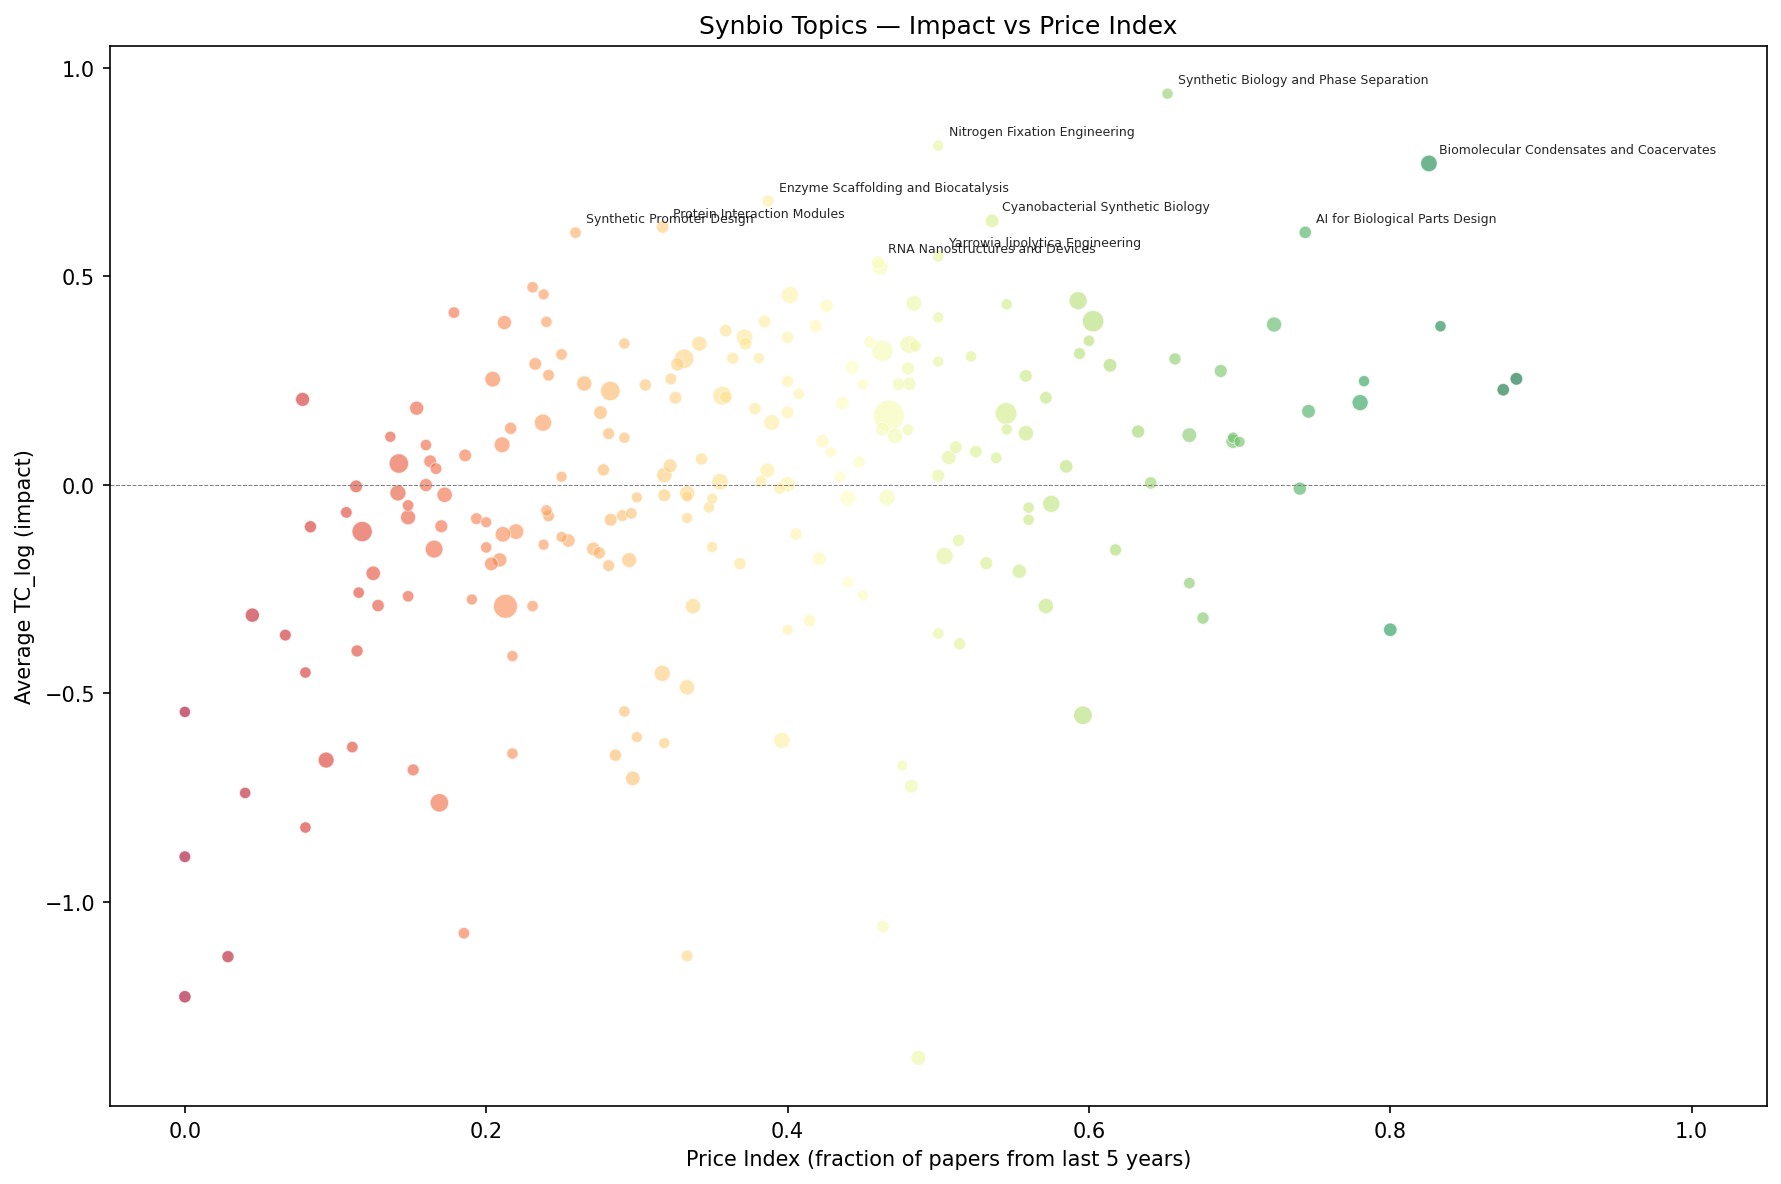

In [6]:
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

sizes = 20 + 200 * (cluster_summary['n_papers'] / cluster_summary['n_papers'].max())

ax.scatter(
    cluster_summary['price_index'],
    cluster_summary['avg_TC_log'],
    s=sizes,
    alpha=0.6,
    edgecolors='white',
    linewidth=0.5,
    c=cluster_summary['price_index'],
    cmap='RdYlGn',
)

top_n = 10
for idx in cluster_summary.nlargest(top_n, 'avg_TC_log').index:
    row = cluster_summary.loc[idx]
    ax.annotate(
        row['global_name'],
        (row['price_index'], row['avg_TC_log']),
        fontsize=6, alpha=0.85,
        textcoords='offset points', xytext=(5, 5),
    )

ax.set_xlabel('Price Index (fraction of papers from last 5 years)')
ax.set_ylabel('Average TC_log (impact)')
ax.set_title('Synbio Topics — Impact vs Price Index')
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlim(-0.05, 1.05)
plt.tight_layout()
fig.savefig(os.path.join(REPORTS, 'impact_vs_price_index.png'), dpi=150, bbox_inches='tight')
print(f"Saved → {os.path.join(REPORTS, 'impact_vs_price_index.png')}")
plt.show()